## TPD data modelling assessment task

Purpose of this task is to get an idea of your data modelling approach.

The dataset is already prepared for you in the .pickle file or .csv files.

Some data exploration charts are below that you may want to add to to help you understand the dataset but we won't spend much time looking that over as this is primarily about the modelling and evaluation.

The ideal submission would be a google colab type notebook or similar that we can access online and run.

Feel free to use LLM tools like ChatGPT but We don't expect large swathes of code to be copied and pasted without concern for how they work, expect to have to answer questions about the any code submitted and thought behind the design decisions.

You can try models based on fast traditional modelling tools like decision trees, GLS, SVM, etc, but in my experience solving the issue of the variable field size becomes much easier using Neural Networks. Ideally Keras or PyTorch should be used in this case.

Again, the main thing under assessment here is modelling ideas/structure and a little about the evaluation interpretation, it's easy to go down big rabbit holes with this data following all sorts of ideas but we're NOT expecting your model to be production ready or even vastly outperform the starting probability. We've already spent years working on similar data, models, and ideas, so of course we're not expecting your model of only a few hours work to be of comparable accuracy to our current best effort.

## Part 1 - Importing the libraries

In [2]:
import tensorflow as tf

tf.config.threading.set_intra_op_parallelism_threads(6)
tf.config.threading.set_inter_op_parallelism_threads(6)

import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from plotly.subplots import make_subplots
from tqdm import tqdm

### Part 2 - Data Preprocessing
### Step 1 : Load Dataset

In [3]:
# load the data
with open("sample_data_interview_task.pickle", "rb") as f:
    (train_race_ids, train_df, train_timelines), (test_race_ids, test_df, test_timelines) = pickle.load(f)

# train_df is sample_data_interview_task_train.csv
# test_df is sample_data_interview_task_test.csv

# focus on just the flat races
train_df = train_df[train_df.pa_race_type_string == "Flat"]
_race_ids = train_df.race_id.unique()
train_timelines = [ x for race_id, x in zip(train_race_ids, train_timelines) if race_id in _race_ids ]
train_race_ids = [ x for x in train_race_ids if x in _race_ids ]

test_df = test_df[test_df.pa_race_type_string == "Flat"]
_race_ids = test_df.race_id.unique()
test_timelines = [ x for race_id, x in zip(test_race_ids, test_timelines) if race_id in _race_ids ]
test_race_ids = [ x for x in test_race_ids if x in _race_ids ]

### dataframe columns

| Field                          | Description                                                                                     |
|-------------------------------|-------------------------------------------------------------------------------------------------|
| V                             | Instantaneous runner speed                                                                      |
| P                             | Instantaneous runner distance remaining to finish line                                          |
| SF                            | Instantaneous runner stride frequency (can be a bit noisy, especially if strides are missed)    |
| start_timestamp               | Start timestamp of the race                                                                     |
| finish_timestamp              | Finish timestamp of the race when first runner crosses the finish line                         |
| timestamp                     | Current timestamp                                                                               |
| timestamp_float               | Same as `.timestamp()`                                                                          |
| race_id                       | Race ID                                                                                         |
| weighted_average_v            | Runner weighted (more recent timestamps weighted higher) average speed over previous 5s         |
| weighted_average_sf           | Runner weighted average stride frequency over previous 10s                                      |
| weighted_average_v_t-1        | Runner weighted average speed at the previous timestamp                                         |
| previous_instantaneous_v      | Runner instantaneous speed at the previous timestamp                                            |
| weighted_average_acceleration | Runner acceleration based on weighted average speed change                                      |
| acceleration                  | Runner instantaneous acceleration based on instantaneous speed change                           |
| gmax_racecourse_name          | Racecourse name                                                                                 |
| gmax_country_code             | Country code                                                                                    |
| gmax_live_win_time            | Finish time of winning horse from live GPS points (±0.1s possible error)                        |
| gmax_race_length              | Race length in meters                                                                           |
| gmax_racetype_label           | Detailed race type description                                                                  |
| surface                       | Surface description                                                                             |
| pa_race_type_string           | Simplified PA race type string                                                                  |
| runner_id                     | Runner ID                                                                                       |
| pa_finish_position            | Runner official finish rank                                                                     |
| pa_price_prob                 | Runner starting price implied probability (includes overround)                                  |
| starting_probability          | Runner starting probability (overround removed, sums to 100%)                                   |
| result                        | Boolean, True if runner won the race, else False                                                |
| inplay                        | Boolean, True if in-running, else False                                                         |
| prob_exchange                 | Probability implied by the exchange market back and lay price midpoint                          |

In your model, DO NOT include the following columns as inputs because they are only available after the race or from sources we are not allowed to use live:
- finish_timestamp
- gmax_live_win_time
- pa_finish_position
- result
- prob_exchange

However you are allowed to use any of those as targets for the model.

The sample_train_timelines and sample_test_timelines are prepared from the dataframes as inputs for a potential model for your convenience, you can use this or create your own model inputs. The timeline format is convenient as it allows you to sample from different timesteps in the timelines during the training loop without having lots of duplicate data in memory in a number of samples.

### Part 1 - Data Preprocessing , Inspect the Dataset

In [4]:
display("data = train_df")
data = train_df.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())
display(data.describe())

display("data = test_df")
data = test_df.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())
display(data.describe())

'data = train_df'

(2144635, 28)

Index(['V', 'P', 'SF', 'start_timestamp', 'finish_timestamp', 'timestamp',
       'timestamp_float', 'race_id', 'weighted_average_v',
       'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_live_win_time', 'gmax_race_length', 'gmax_racetype_label',
       'surface', 'pa_race_type_string', 'runner_id', 'pa_finish_position',
       'pa_price_prob', 'starting_probability', 'result', 'inplay',
       'prob_exchange'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 2144635 entries, 0 to 4633572
Data columns (total 28 columns):
 #   Column                         Dtype                  
---  ------                         -----                  
 0   V                              float64                
 1   P                              float64                
 2   SF                             float64                
 3   start_timestamp                datetime64[us, tzutc()]
 4   finish_timestamp               datetime64[us, tzutc()]
 5   timestamp                      datetime64[ns, UTC]    
 6   timestamp_float                float64                
 7   race_id                        int64                  
 8   weighted_average_v             float64                
 9   weighted_average_sf            float64                
 10  weighted_average_v_t-1         float64                
 11  previous_instantaneous_v       float64                
 12  weighted_average_acceleration  float64         

None

...

<class 'pandas.core.frame.DataFrame'>
Index: 715617 entries, 0 to 1629119
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype                  
---  ------                         --------------   -----                  
 0   V                              715617 non-null  float64                
 1   P                              715617 non-null  float64                
 2   SF                             582455 non-null  float64                
 3   start_timestamp                715617 non-null  datetime64[us, tzutc()]
 4   finish_timestamp               715617 non-null  datetime64[us, tzutc()]
 5   timestamp                      715617 non-null  datetime64[ns, UTC]    
 6   timestamp_float                715617 non-null  float64                
 7   race_id                        715617 non-null  int64                  
 8   weighted_average_v             715617 non-null  float64                
 9   weighted_average_sf            556868 non

None

,V,P,SF,start_timestamp,finish_timestamp,timestamp,timestamp_float,race_id,weighted_average_v,weighted_average_sf,...,gmax_racetype_label,surface,pa_race_type_string,runner_id,pa_finish_position,pa_price_prob,starting_probability,result,inplay,prob_exchange
0,11.53,1568.7,2.23,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:56+00:00,1.678201e+09,8170814705910533503,7.945333,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.360554
1,12.41,1554.9,2.23,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:57+00:00,1.678201e+09,8170814705910533503,10.083333,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.360547
2,13.58,1539.3,2.23,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:58+00:00,1.678201e+09,8170814705910533503,11.812667,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.364484
3,14.29,1523.7,2.20,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:51:59+00:00,1.678201e+09,8170814705910533503,12.999333,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.374509
4,14.49,1508.4,2.21,2023-03-07 14:51:50.630000+00:00,2023-03-07 14:53:28.430000+00:00,2023-03-07 14:52:00+00:00,1.678201e+09,8170814705910533503,13.780000,NaN,...,Lingfield 1M1y PT,AW,Flat,2048253577013069783,1.0,0.380952,0.352858,True,True,0.403128


,V,P,SF,start_timestamp,finish_timestamp,timestamp,timestamp_float,race_id,weighted_average_v,weighted_average_sf,...,gmax_racetype_label,surface,pa_race_type_string,runner_id,pa_finish_position,pa_price_prob,starting_probability,result,inplay,prob_exchange
1629115,14.33,60.95,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:02+00:00,1.692215e+09,2738939371834362428,14.316667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002730
1629116,14.30,46.87,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:03+00:00,1.692215e+09,2738939371834362428,14.310667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002572
1629117,14.21,33.01,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:04+00:00,1.692215e+09,2738939371834362428,14.276667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002495
1629118,14.05,19.58,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:05+00:00,1.692215e+09,2738939371834362428,14.197333,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002812
1629119,13.74,6.28,NaN,2023-08-16 19:35:39.500000+00:00,2023-08-16 19:38:06.630000+00:00,2023-08-16 19:38:06+00:00,1.692215e+09,2738939371834362428,14.030667,NaN,...,Kempton 1m2f219y AW Outer Loop,AW,Flat,2987291509971895451,9.0,0.1,0.082425,False,True,0.002812


,V,P,SF,timestamp_float,race_id,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,weighted_average_acceleration,acceleration,gmax_live_win_time,gmax_race_length,runner_id,pa_finish_position,pa_price_prob,starting_probability,prob_exchange
count,715617.000000,715617.000000,582455.000000,7.156170e+05,7.156170e+05,715617.000000,556868.000000,715612.000000,715612.000000,715612.000000,715612.000000,582502.000000,715617.000000,7.156170e+05,714498.000000,715617.000000,715617.000000,7.156170e+05
mean,16.091658,910.231256,2.243527,1.688721e+09,4.572001e+18,16.010759,2.243517,15.933596,16.052089,0.077274,0.039681,118.519787,1845.805542,4.638540e+18,5.395486,0.129158,0.110707,1.063297e-01
std,1.365278,630.121566,0.229822,8.036059e+06,2.726524e+18,1.553906,0.167597,1.786765,1.471492,0.392804,0.335263,43.142617,610.561096,2.663925e+18,3.241302,0.113382,0.106398,1.512496e-01
min,0.020000,0.210000,0.280000,1.672594e+09,1.415244e+16,0.020000,0.413273,0.013333,0.000000,-5.340000,-16.410000,55.830000,1000.400024,1.379139e+15,1.000000,0.003322,0.001140,7.226493e-210
25%,15.300000,408.800000,2.170000,1.681834e+09,2.122296e+18,15.270000,2.164182,15.248000,15.280000,-0.073333,-0.100000,86.330000,1409.099976,2.343120e+18,3.000000,0.047619,0.034856,9.757491e-03
50%,16.130000,819.400000,2.270000,1.690391e+09,4.435174e+18,16.113333,2.252727,16.106000,16.120000,-0.005333,0.000000,105.710000,1621.199951,4.644617e+18,5.000000,0.100000,0.080614,5.448739e-02
75%,17.000000,1278.400000,2.360000,1.694114e+09,7.125417e+18,16.981333,2.345091,16.978000,17.000000,0.073333,0.100000,150.740000,2338.100098,6.949970e+18,8.000000,0.181818,0.154837,1.384249e-01
max,20.200000,3710.000000,2.790000,1.704037e+09,9.211237e+18,20.058667,2.735273,20.058667,20.200000,4.258000,10.370000,261.350000,3749.000000,9.222706e+18,27.000000,0.875000,0.858559,9.912544e-01


#### Sample only 50% of unique race_ids to reduce the dataset size and aviod duplicate (replace=False)

In [5]:
np.random.seed(42)
sample_train_races = np.random.choice(train_df.race_id.unique(), size=int(len(train_df.race_id.unique()) * 0.2), replace=False)
sample_test_races = np.random.choice(test_df.race_id.unique(), size=int(len(test_df.race_id.unique()) * 0.2), replace=False)

train_df = train_df[train_df.race_id.isin(sample_train_races)]
test_df = test_df[test_df.race_id.isin(sample_test_races)]

### Step 2 : Check Missing Values

In [6]:
display("data = train_df")
data = train_df.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts,'Missing_Percentage': missing_percentage.round(2)})
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))
columns_with_missing_train = missing_summary[missing_summary['Missing_Count'] > 0].index.tolist()
display(columns_with_missing_train)

display("data = test_df")
data = test_df.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts,'Missing_Percentage': missing_percentage.round(2)})
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))
columns_with_missing_test = missing_summary[missing_summary['Missing_Count'] > 0].index.tolist()
display(columns_with_missing_test)

'data = train_df'

,Missing_Count,Missing_Percentage
weighted_average_sf,92945,21.15
SF,77048,17.54
gmax_live_win_time,77016,17.53
pa_finish_position,1319,0.30
V,0,0.00
gmax_country_code,0,0.00
inplay,0,0.00
result,0,0.00
starting_probability,0,0.00
pa_price_prob,0,0.00


['SF',
 'weighted_average_sf',
 'weighted_average_v_t-1',
 'previous_instantaneous_v',
 'weighted_average_acceleration',
 'acceleration',
 'gmax_live_win_time',
 'pa_finish_position']

'data = test_df'

,Missing_Count,Missing_Percentage
weighted_average_sf,36933,26.82
SF,32250,23.42
gmax_live_win_time,32247,23.41
pa_finish_position,232,0.17
V,0,0.00
gmax_country_code,0,0.00
inplay,0,0.00
result,0,0.00
starting_probability,0,0.00
pa_price_prob,0,0.00


['SF',
 'weighted_average_sf',
 'weighted_average_v_t-1',
 'previous_instantaneous_v',
 'weighted_average_acceleration',
 'acceleration',
 'gmax_live_win_time',
 'pa_finish_position']

### Function for advanced feature engineering

| Feature Name                  | Description  (Why It’s Likely Useful)                                                           |
|-------------------------------|-------------------------------------------------------------------------------------------------|
| race_completion               | Normalizes position (P) by race length – useful to know how far into the race we are.           |
| time_since_start              | Helps models understand race progression and time dynamics.                                     |
| relative_position             | Gives relative rank per timestamp – very informative for race.                                  |
| relative_speed                | Contextualizes a runner's speed relative to others at the same time.                            |
| distance_to_leader            | Highlights how far a runner is from the leader – useful for predicting overtakes.               |
| normalized_distance_to_leader | Same, but normalized – good for consistency across races of different lengths.                  |
| speed_momentum                | Detects sudden changes in speed – a strong signal of surges or drops.                           |
| position_change_rate          | Tracks if the runner is gaining or losing rank over time – a great dynamic feature.             |

In [7]:
def create_advanced_features(df):
    """Create additional advanced features for the model"""
    # Base features
    df['race_completion'] = 1 - (df['P'] / df['gmax_race_length'])
    df['time_since_start'] = df.groupby('race_id')['timestamp_float'].transform(lambda x: x - x.min())
    df['relative_position'] = df.groupby(['race_id', 'timestamp'])['P'].rank(pct=True)
    
    # Advanced features
    # Calculate speed relative to race average
    df['relative_speed'] = df.groupby(['race_id', 'timestamp'])['V'].transform(lambda x: x / x.mean())
    
    # Distance to leader
    df['distance_to_leader'] = df.groupby(['race_id', 'timestamp'])['P'].transform('min') - df['P']
    df['normalized_distance_to_leader'] = df['distance_to_leader'] / df['gmax_race_length']
    
    # Speed momentum (current vs previous)
    df['speed_momentum'] = df['V'] / df.groupby(['race_id', 'runner_id'])['V'].shift(1)
    df['speed_momentum'] = df['speed_momentum'].fillna(1.0)
    
    # Position change rate
    df['position_change_rate'] = df.groupby(['race_id', 'runner_id'])['relative_position'].diff()
    df['position_change_rate'] = df['position_change_rate'].fillna(0)
    
    # Clean up any infinity or NaN values
    for col in df.columns:
        if df[col].dtype in [np.float16, np.float32, np.float64]:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
            df[col] = df[col].fillna(df[col].median())
    
    return df

# Feature engineering (enhanced version)
print("Creating advanced features...")
train_df = create_advanced_features(train_df)
display("Advanced features created for train")
test_df = create_advanced_features(test_df)
display("Advanced features created for test")

Creating advanced features...


'Advanced features created for train'

'Advanced features created for test'

 #### Handle the outliers
Cleans outliers using a hybrid approach:
1. Filters data to within hard_bounds.
2. Clips remaining values to quantile range.

In [8]:
# Define the hybrid outlier cleaning function
def clean_outliers_hybrid(df, col, hard_bounds, clip_quantiles=(0.01, 0.99)):
    df = df[(df[col] >= hard_bounds[0]) & (df[col] <= hard_bounds[1])].copy()
    lower, upper = df[col].quantile(clip_quantiles)
    df[col] = df[col].clip(lower, upper)
    return df

# Apply the cleaning function to your DataFrame
data = train_df.copy()

data = clean_outliers_hybrid(data, 'position_change_rate', (-0.5, 0.5))
data = clean_outliers_hybrid(data, 'relative_speed', (0.5, 2.0))
data = clean_outliers_hybrid(data, 'distance_to_leader', (-50, 1000))
data = clean_outliers_hybrid(data, 'speed_momentum', (0., 5.0))

train_df = data.copy()
train_df_N = train_df.copy()

#### List of columns need to be removed
Drop them from X_train and X_test

In [9]:

forbidden_columns = [
    'finish_timestamp',
    'gmax_live_win_time',
    'pa_finish_position',
    'prob_exchange',
    'runner_id',
    'race_id',
    'result'
]

train_df_N = train_df.drop(columns=forbidden_columns)
test_df_N = test_df.drop(columns=forbidden_columns)

### Step 3 : Final Data Inspection 

In [10]:
data = train_df_N.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percentage': missing_percentage.round(2) })
display("data = train_df_N")
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))

data = test_df_N.copy()
missing_counts = data.isnull().sum()
missing_percentage = (missing_counts / len(data)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percentage': missing_percentage.round(2) })
display("data = test_df_N")
display(missing_summary.sort_values(by='Missing_Percentage', ascending=False))

'data = train_df_N'

,Missing_Count,Missing_Percentage
V,0,0.0
gmax_racetype_label,0,0.0
speed_momentum,0,0.0
normalized_distance_to_leader,0,0.0
distance_to_leader,0,0.0
relative_speed,0,0.0
relative_position,0,0.0
time_since_start,0,0.0
race_completion,0,0.0
inplay,0,0.0


'data = test_df_N'

,Missing_Count,Missing_Percentage
V,0,0.0
gmax_racetype_label,0,0.0
speed_momentum,0,0.0
normalized_distance_to_leader,0,0.0
distance_to_leader,0,0.0
relative_speed,0,0.0
relative_position,0,0.0
time_since_start,0,0.0
race_completion,0,0.0
inplay,0,0.0


In [11]:
display("data = train_df_N")
data = train_df_N.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())
display(data.describe())

display("data = test_df_N")
data = test_df_N.copy()
display(data.shape)
display(data.columns)
display(data.info())
display(data.head())
display(data.tail())

'data = train_df_N'

(434562, 29)

Index(['V', 'P', 'SF', 'start_timestamp', 'timestamp', 'timestamp_float',
       'weighted_average_v', 'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_race_length', 'gmax_racetype_label', 'surface',
       'pa_race_type_string', 'pa_price_prob', 'starting_probability',
       'inplay', 'race_completion', 'time_since_start', 'relative_position',
       'relative_speed', 'distance_to_leader', 'normalized_distance_to_leader',
       'speed_momentum', 'position_change_rate'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 434562 entries, 52019 to 4633572
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype                  
---  ------                         --------------   -----                  
 0   V                              434562 non-null  float64                
 1   P                              434562 non-null  float64                
 2   SF                             434562 non-null  float64                
 3   start_timestamp                434562 non-null  datetime64[us, tzutc()]
 4   timestamp                      434562 non-null  datetime64[ns, UTC]    
 5   timestamp_float                434562 non-null  float64                
 6   weighted_average_v             434562 non-null  float64                
 7   weighted_average_sf            434562 non-null  float64                
 8   weighted_average_v_t-1         434562 non-null  float64                
 9   previous_instantaneous_v       434562

None

...

Index(['V', 'P', 'SF', 'start_timestamp', 'timestamp', 'timestamp_float',
       'weighted_average_v', 'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_race_length', 'gmax_racetype_label', 'surface',
       'pa_race_type_string', 'pa_price_prob', 'starting_probability',
       'inplay', 'race_completion', 'time_since_start', 'relative_position',
       'relative_speed', 'distance_to_leader', 'normalized_distance_to_leader',
       'speed_momentum', 'position_change_rate'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
Index: 137729 entries, 11846 to 1607108
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype                  
---  ------                         --------------   -----                  
 0   V                              137729 non-null  float64                
 1   P                              137729 non-null  float64                
 2   SF                             137729 non-null  float64                
 3   start_timestamp                137729 non-null  datetime64[us, tzutc()]
 4   timestamp                      137729 non-null  datetime64[ns, UTC]    
 5   timestamp_float                137729 non-null  float64                
 6   weighted_average_v             137729 non-null  float64                
 7   weighted_average_sf            137729 non-null  float64                
 8   weighted_average_v_t-1         137729 non-null  float64                
 9   previous_instantaneous_v       137729

None

,V,P,SF,start_timestamp,timestamp,timestamp_float,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,...,starting_probability,inplay,race_completion,time_since_start,relative_position,relative_speed,distance_to_leader,normalized_distance_to_leader,speed_momentum,position_change_rate
11846,15.04,968.8,1.15,2023-12-05 18:01:16.840000+00:00,2023-12-05 18:01:23+00:00,1.701799e+09,11.211333,2.260182,8.188000,12.47,...,0.174615,True,0.054829,0.0,0.4,1.089066,-2.2,-0.002146,1.000000,0.0
11847,15.79,950.4,1.92,2023-12-05 18:01:16.840000+00:00,2023-12-05 18:01:24+00:00,1.701799e+09,13.482000,2.260182,11.211333,15.04,...,0.174615,True,0.072780,1.0,0.3,1.067036,-1.5,-0.001463,1.049867,-0.1
11848,17.05,931.8,2.75,2023-12-05 18:01:16.840000+00:00,2023-12-05 18:01:25+00:00,1.701799e+09,15.252667,2.260182,13.482000,15.79,...,0.174615,True,0.090927,2.0,0.3,1.070308,-1.1,-0.001073,1.079797,0.0
11849,17.56,912.5,2.73,2023-12-05 18:01:16.840000+00:00,2023-12-05 18:01:26+00:00,1.701799e+09,16.394667,2.260182,15.252667,17.05,...,0.174615,True,0.109756,3.0,0.3,1.054718,-0.9,-0.000878,1.029912,0.0
11850,18.53,892.8,2.22,2023-12-05 18:01:16.840000+00:00,2023-12-05 18:01:27+00:00,1.701799e+09,17.377333,2.260182,16.394667,17.56,...,0.174615,True,0.128976,4.0,0.2,1.070727,-0.6,-0.000585,1.055239,-0.1


,V,P,SF,start_timestamp,timestamp,timestamp_float,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,...,starting_probability,inplay,race_completion,time_since_start,relative_position,relative_speed,distance_to_leader,normalized_distance_to_leader,speed_momentum,position_change_rate
1607104,14.91,152.8,2.16,2023-05-25 14:52:13.700000+00:00,2023-05-25 14:53:24+00:00,1.685026e+09,14.834667,2.237818,14.810667,14.72,...,0.006378,True,0.875296,66.0,1.0,0.920598,-83.9,-0.068473,1.012908,0.0
1607105,14.82,138.2,2.24,2023-05-25 14:52:13.700000+00:00,2023-05-25 14:53:25+00:00,1.685026e+09,14.825333,2.240727,14.834667,14.91,...,0.006378,True,0.887211,67.0,1.0,0.926366,-85.0,-0.069371,0.993964,0.0
1607106,14.69,123.6,2.25,2023-05-25 14:52:13.700000+00:00,2023-05-25 14:53:26+00:00,1.685026e+09,14.776000,2.247273,14.825333,14.82,...,0.006378,True,0.899127,68.0,1.0,0.929747,-86.4,-0.070513,0.991228,0.0
1607107,14.44,109.2,2.31,2023-05-25 14:52:13.700000+00:00,2023-05-25 14:53:27+00:00,1.685026e+09,14.664000,2.263273,14.776000,14.69,...,0.006378,True,0.910879,69.0,1.0,0.922448,-87.9,-0.071738,0.982982,0.0
1607108,14.33,95.1,2.16,2023-05-25 14:52:13.700000+00:00,2023-05-25 14:53:28+00:00,1.685026e+09,14.535333,2.247455,14.664000,14.44,...,0.006378,True,0.922386,70.0,1.0,0.924994,-89.5,-0.073043,0.992382,0.0


### Part 3 - Insights and Visulization
#### 1. Exploratory Data Analysis (EDA) and Summary Statistics

### Step 1 : Select Data

In [12]:
selected_features  = [ 
# Original features
        'V',   # Speed
        'P',   # Distance remaining
        'SF',  # Stride frequency
        'weighted_average_v',             # Weighted average speed
        'weighted_average_acceleration',  # Acceleration
        'acceleration',                   # Instantaneous acceleration
        'starting_probability',           # Starting probability
        
        # Engineered features
        'race_completion',                # Race completion percentage
        'time_since_start',               # Time since race start
        'relative_position',              # Relative position
        'relative_speed',                 # Speed relative to race average
        'distance_to_leader',             # Distance to leader
        'normalized_distance_to_leader',  # Normalized distance to leader
        'speed_momentum',                 # Speed momentum
        'position_change_rate',           # Position change rate
    ]

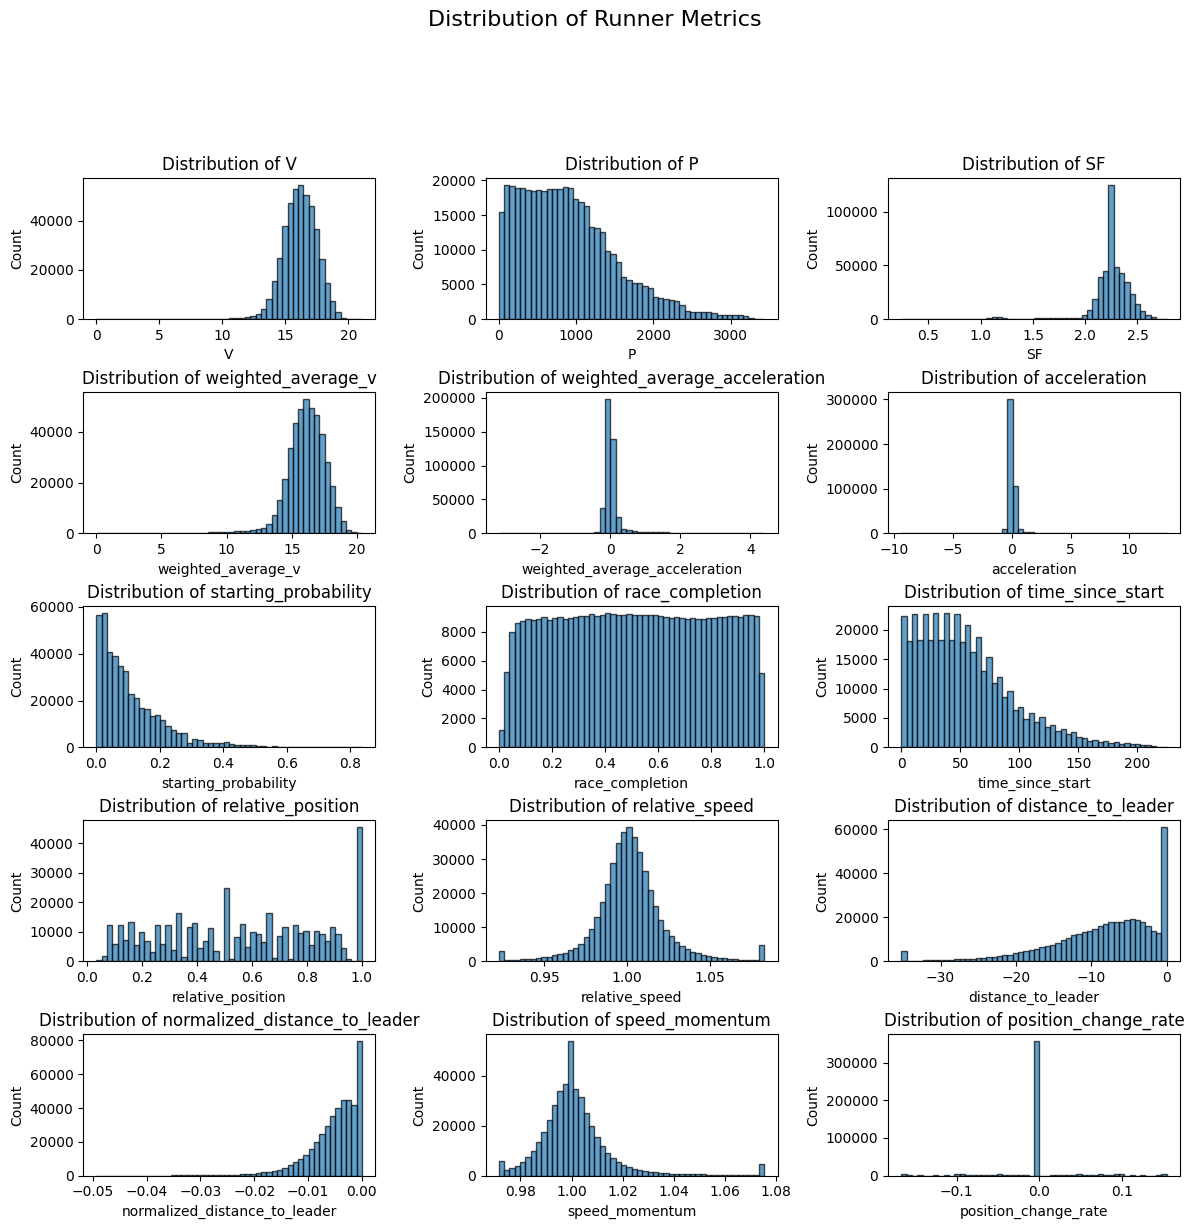

In [13]:
columns_to_plot = selected_features

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    ax.hist(train_df_N[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.suptitle("Distribution of Runner Metrics", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.88)
plt.show()

#### Compute the correlation matrix for the selected numeric columns

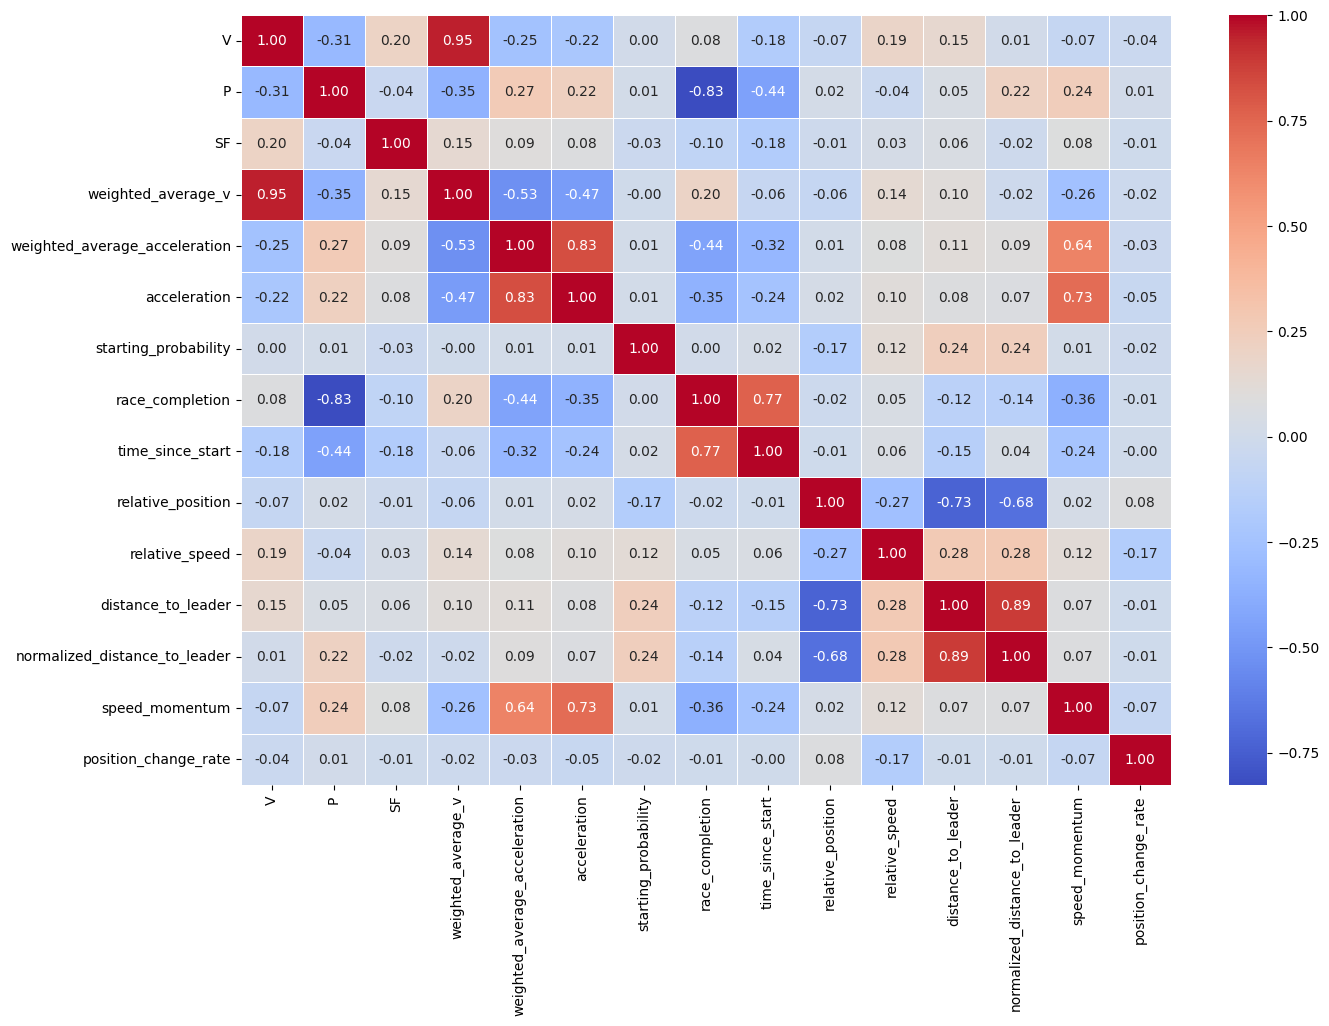

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = train_df_N[selected_features].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [66]:
X = train_df_N.copy()
display(X.columns)
#X = train_df_N[selected_features].copy()
y = train_df['result']

# Handle categorical columns (One-hot encode any categorical columns)
X = pd.get_dummies(X)  

# Convert any True/False into 1/0
#X = X.astype('int64')

display(X)

Index(['V', 'P', 'SF', 'start_timestamp', 'timestamp', 'timestamp_float',
       'weighted_average_v', 'weighted_average_sf', 'weighted_average_v_t-1',
       'previous_instantaneous_v', 'weighted_average_acceleration',
       'acceleration', 'gmax_racecourse_name', 'gmax_country_code',
       'gmax_race_length', 'gmax_racetype_label', 'surface',
       'pa_race_type_string', 'pa_price_prob', 'starting_probability',
       'inplay', 'race_completion', 'time_since_start', 'relative_position',
       'relative_speed', 'distance_to_leader', 'normalized_distance_to_leader',
       'speed_momentum', 'position_change_rate'],
      dtype='object')

,V,P,SF,start_timestamp,timestamp,timestamp_float,weighted_average_v,weighted_average_sf,weighted_average_v_t-1,previous_instantaneous_v,...,gmax_racetype_label_York 1M5f188y Flat,gmax_racetype_label_York 2M56y Flat,gmax_racetype_label_York 5f Flat,gmax_racetype_label_York 5f89y Flat,gmax_racetype_label_York 6f Flat,gmax_racetype_label_York 7f Flat,gmax_racetype_label_York 7f192y Flat,surface_AW,surface_Turf,pa_race_type_string_Flat
7182,13.85,1170.5,2.45,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:10+00:00,1.686924e+09,10.432667,2.254000,7.608000,12.03,...,False,False,False,False,False,False,False,False,True,True
7183,14.65,1153.8,2.42,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:11+00:00,1.686924e+09,12.600667,2.254000,10.432667,13.85,...,False,False,False,False,False,False,False,False,True,True
7184,16.07,1136.2,2.41,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:12+00:00,1.686924e+09,14.292667,2.254000,12.600667,14.65,...,False,False,False,False,False,False,False,False,True,True
7185,16.48,1118.2,2.47,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:13+00:00,1.686924e+09,15.357333,2.254000,14.292667,16.07,...,False,False,False,False,False,False,False,False,True,True
7186,17.34,1099.7,2.51,2023-06-16 13:52:03.940000+00:00,2023-06-16 13:52:14+00:00,1.686924e+09,16.265333,2.254000,15.357333,16.48,...,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4633568,16.29,72.7,2.12,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:24+00:00,1.688217e+09,16.339333,2.130909,16.382667,16.33,...,False,False,False,False,False,False,False,False,True,True
4633569,16.28,56.5,2.13,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:25+00:00,1.688217e+09,16.307333,2.129455,16.339333,16.29,...,False,False,False,False,False,False,False,False,True,True
4633570,15.94,40.6,2.06,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:26+00:00,1.688217e+09,16.180000,2.116000,16.307333,16.28,...,False,False,False,False,False,False,False,False,True,True
4633571,15.84,25.1,2.08,2023-07-01 13:10:56.720000+00:00,2023-07-01 13:13:27+00:00,1.688217e+09,16.047333,2.108182,16.180000,15.94,...,False,False,False,False,False,False,False,False,True,True


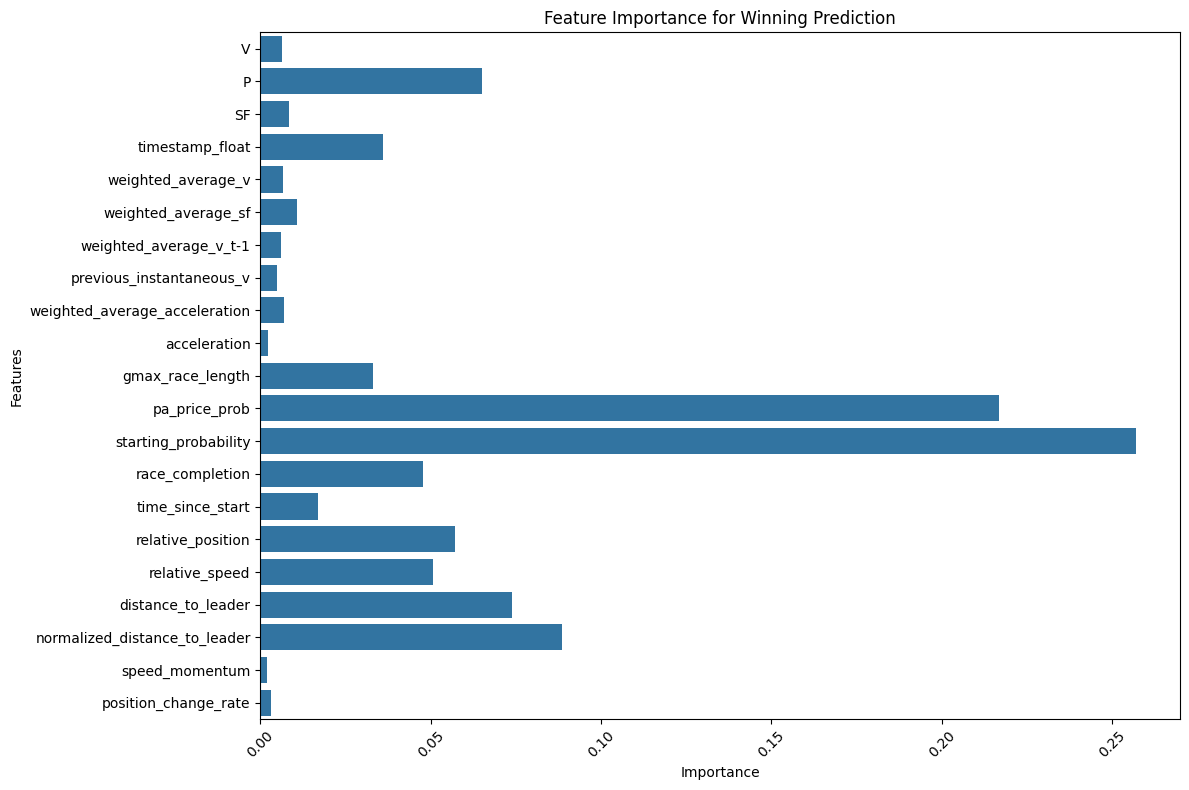

In [67]:
# Remove non-numeric columns 
X = X.select_dtypes(include=[np.number])

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42,  n_jobs=-1)

#model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.title('Feature Importance for Winning Prediction')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Check class distribution

In [68]:
# Check full distribution of result
class_counts = train_df['result'].value_counts()

# Display full counts
display(class_counts)

# Access counts individually
false_count = class_counts.get(False, 0)
true_count = class_counts.get(True, 0)

display(f"Complete rows for result = False: {false_count}")
display(f"Complete rows for result = True: {true_count}")

# Now print the ratio (True / False)
if false_count > 0:  # Avoid division by zero
    ratio = true_count / false_count
    display(f"Ratio (True : False) = {ratio:.4f}")
else:
    display("No False cases found to calculate the ratio.")

result
False    956825
True     121958
Name: count, dtype: int64

'Complete rows for result = False: 956825'

'Complete rows for result = True: 121958'

'Ratio (True : False) = 0.1275'

| Model Name     | Description (Why It’s Likely Useful)                                                                                         |
|----------------|-------------------------------------------------------------------------------------------------------------------------------|
| ANN (Artificial Neural Network) | Learns complex nonlinear relationships in horse racing data using dense layers and activation functions. Useful when patterns between features (like speed, position, probability) are not linearly separable. Flexible and general-purpose model that adapts well with enough data. |
| XGBoost         | Gradient boosting framework that sequentially corrects prediction errors. Strong at capturing interactions, handling missing data, and managing class imbalance. Often achieves state-of-the-art performance in structured/tabular datasets like horse race records. |
| Random Forest   | Ensemble of decision trees trained in parallel. Good baseline that’s robust to overfitting and noise. Useful when you want reliable predictions with interpretability (e.g., feature importance) and when interactions are less complex than those captured by XGBoost or ANN. |


# Part  5 - Winner Prediction 
### Step 1 : Splitting the dataset into the Training set and Test set

In [18]:
# Create a new DataFrame with only the selected features
X_train = train_df_N[selected_features]
X_test = test_df_N[selected_features]

# Your label (target to predict) is 'result'
y_train = train_df['result'].astype(int)
y_test = test_df['result'].astype(int)

In [19]:
display(y_train,y_test)

52019      1
52020      1
52021      1
52022      1
52023      1
          ..
4633568    1
4633569    1
4633570    1
4633571    1
4633572    1
Name: result, Length: 434562, dtype: int32

11846      0
11847      0
11848      0
11849      0
11850      0
          ..
1607104    0
1607105    0
1607106    0
1607107    0
1607108    0
Name: result, Length: 137729, dtype: int32

In [16]:
# Check features for NaNs
assert not X_train.isnull().any().any(), "X_train contains NaNs"
assert not X_test.isnull().any().any(), "X_test contains NaNs"

# Check labels for NaNs and class validity
def check_binary_labels(y, name="target"):
    assert not y.isnull().any(), f"{name} contains NaNs"
    assert set(y.unique()).issubset({0, 1}), f"Unexpected values in {name}"

check_binary_labels(y_train, "y_train")
check_binary_labels(y_test, "y_test")

In [22]:
from sklearn.model_selection import train_test_split
X_train_sel, X_val_sel, y_train_sel, y_val_sel = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

#### Part 1 : Winner Prediction with Random Forest
#### Step 2 : Initializing the Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf = RandomForestClassifier(random_state=2024,n_jobs=-1) 

#### Step 3 : Training the Random Forest

| Hyperparameter Name           | Description (Why It’s Likely Useful)                                                             |
|------------------------------|--------------------------------------------------------------------------------------------------|
| bootstrap                    | Whether bootstrap samples are used when building trees. Set to `True` to reduce variance. Random Forest reduces overfitting by averaging predictions from diverse trees        |
| criterion                    | Function to measure the quality of a split (e.g., 'gini' or 'entropy'). Affects how trees learn. |
| max_depth                    | Maximum depth of each tree. Limits model complexity and helps prevent overfitting.               |
| max_features                 | Number of features to consider when looking for the best split. Controls diversity among trees.  |
| min_samples_leaf            | Minimum samples required at a leaf node. Higher values smooth the model and reduce overfitting.  |
| min_samples_split           | Minimum samples required to split an internal node. Controls how deep the tree can grow.         |
| n_estimators                | Number of trees in the forest. More trees usually mean better performance but slower training.    |
| random_state                | Seed for random number generator. Ensures reproducibility of results.                             |
| n_jobs                      | Number of CPU cores used for training. `-1` uses all available cores for faster training.          |


In [26]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = { 
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2', None],  
    'max_depth': [10, 20, 30],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [5, 10],
    'bootstrap': [True, False]
}

# Use RandomizedSearchCV with fewer total models (n_iter=30)
CV_rfc = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=5,             # Try only 30 random combinations instead of all 288
    cv=2,                  # 3-fold cross-validation
    n_jobs=6,
    verbose=1,
    random_state=42
)

CV_rfc.fit(X_train, y_train)
print("Best Parameters:", CV_rfc.best_params_)


Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'gini', 'bootstrap': False}


#### Feed with the best_params

In [28]:
rf_final=RandomForestClassifier(
    bootstrap=True,
    criterion='entropy',
    max_depth=10, 
    max_features='sqrt',
    min_samples_leaf=5,
    min_samples_split = 10,
    n_estimators= 100, 
    random_state=2024,
    n_jobs=-1)

rf_final.fit(X_train_sel, y_train_sel)

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=5,
                       min_samples_split=10, n_jobs=-1, random_state=2024)

### Part 2 - Winner Prediction with XGBoost
### Step 1 : Initialize XGBoost Classifier

In [31]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric=['logloss', 'auc'],
    random_state=42
)

#### Step 2 : Training the XGB
#### Training the XGB on the Training set Perform Grid Search to find the best_params

| Hyperparameter Name           | Description (Why It’s Likely Useful)                                                             |
|------------------------------|--------------------------------------------------------------------------------------------------|
| objective                    | Specifies the learning task. `'binary:logistic'` is used for binary classification problems.      |
| eval_metric                  | Evaluation metric for validation data. `'logloss'` is good for probabilistic classification.      |
| n_estimators                 | Number of boosting rounds (trees). More trees can improve accuracy but increase training time.    |
| learning_rate                | Step size shrinkage used in updates. Lower values improve generalization but require more trees.  |
| max_depth                    | Maximum depth of each tree. Controls model complexity and helps prevent overfitting.              |
| min_child_weight             | Minimum sum of instance weights needed in a child. Larger values make the algorithm more conservative. |
| gamma                        | Minimum loss reduction required to make a further partition. Acts as regularization to prevent over-splitting. |
| subsample                    | Fraction of training samples used for each tree. Helps prevent overfitting and adds randomness.   |
| colsample_bytree             | Fraction of features used for each tree. Reduces correlation among trees and improves generalization. |
| random_state                 | Seed for reproducibility. Ensures results can be replicated.                                      |


In [33]:
from sklearn.model_selection import RandomizedSearchCV

# Use the same parameter space as before
param_distributions = {
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.2, 0.5, 1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 3, 5, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

# Apply RandomizedSearchCV with a reasonable number of iterations
CV_xgb_model = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=30,             # Try 30 random combinations instead of full grid (~10368)
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

CV_xgb_model.fit(X_train, y_train)

print("Best Parameters:", CV_xgb_model.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}


#### Feed with the best_params

In [32]:
xgb_model_final = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=2000,         # Allow early stopping to cut off early
    learning_rate=0.1,       # Lower = better generalization
    max_depth=3,              # More conservative depth
    min_child_weight=1,
    gamma=0,                  # Start with 0 unless you see over-splitting
    subsample=0.8,            # Add randomness to reduce overfitting
    colsample_bytree=0.6,     # Use a subset of features per tree
    random_state=2024
)

xgb_model_final.fit(
    X_train_sel, y_train_sel,
    eval_set=[(X_val_sel, y_val_sel)],
    verbose=True
)

[0]	validation_0-logloss:0.33744
[1]	validation_0-logloss:0.33083
[2]	validation_0-logloss:0.32619
[3]	validation_0-logloss:0.32257
[4]	validation_0-logloss:0.31969
[5]	validation_0-logloss:0.31668
[6]	validation_0-logloss:0.30981
[7]	validation_0-logloss:0.30442
[8]	validation_0-logloss:0.30003
[9]	validation_0-logloss:0.29627
[10]	validation_0-logloss:0.29462
[11]	validation_0-logloss:0.29159
[12]	validation_0-logloss:0.29029
[13]	validation_0-logloss:0.28911
[14]	validation_0-logloss:0.28828
[15]	validation_0-logloss:0.28704
[16]	validation_0-logloss:0.28473
[17]	validation_0-logloss:0.28276
[18]	validation_0-logloss:0.28110
[19]	validation_0-logloss:0.28035
[20]	validation_0-logloss:0.27889
[21]	validation_0-logloss:0.27767
[22]	validation_0-logloss:0.27658
[23]	validation_0-logloss:0.27568
[24]	validation_0-logloss:0.27490
[25]	validation_0-logloss:0.27419
[26]	validation_0-logloss:0.27346
[27]	validation_0-logloss:0.27311
[28]	validation_0-logloss:0.27264
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2000, n_jobs=None,
              num_parallel_tree=None, ...)

### Part 3 - Winner Prediction with Building the ANN
#### Step 2 : Feature Scaling

In [33]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_ANN = sc.fit_transform(X_train)
X_test_ANN = sc.transform(X_test)

In [34]:
assert not X_train.isnull().any().any()
assert not X_test.isnull().any().any()

### Step 4 : Training the ANN
### Compiling the ANN
### Training the ANN on the Training set

| Layer Name                   | Description (Why It’s Likely Useful)                                                              |
|-----------------------------|---------------------------------------------------------------------------------------------------|
| Input(shape=input_shape)    | Defines the input shape expected by the model. Required for the first layer in a Sequential model. |
| Dense(128)                  | Fully connected layer with 128 units. Learns representations from input features.                 |
| BatchNormalization()        | Normalizes activations to speed up training and stabilize learning. Often improves performance.  |
| LeakyReLU(0.1)              | Activation function (Rectifier) that allows a small gradient when units are inactive. Helps avoid dying neurons. |
| Dropout(0.4)                | Randomly sets 40% of the units to 0 during training. Prevents overfitting by adding noise.        |
| Dense(1, activation='sigmoid') | Output layer for binary classification. Sigmoid activation converts output to a probability.  |


Adam optimizer because it is one of the most efficient and reliable optimization algorithms for training deep learning models — especially when: data is noisy or sparse, network is deep, want faster convergence without manually tuning momentum or learning rate schedules.

In [38]:
def create_improved_model(input_shape, learning_rate=0.01):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),        
        tf.keras.layers.Dense(128),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Dense(64),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(32),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.LeakyReLU(negative_slope=0.1),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # Use a fixed learning rate so ReduceLROnPlateau can adjust it
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model


| EarlyStopping     | Stops training early if validation AUC doesn’t improve for a number of epochs (patience=10). Prevents overfitting and saves time.                                                          |
|-----------------------------|---------------------------------------------------------------------------------------------------|
| monitor                     | Metric to watch on the validation set (`'val_auc'`). Training will stop if this doesn't improve.  |
| patience                    | Number of epochs to wait without improvement before stopping. Helps avoid premature stopping.      |
| mode                        | `'max'` means we expect the monitored metric to increase. Used when higher = better (e.g., AUC).   |
| restore_best_weights        | Restores the weights from the epoch with the best monitored score, not the final one. Ensures best performance is preserved. |
| verbose                     | Controls the amount of logging output. `1` prints messages when early stopping is triggered.       |


|ReduceLROnPlateau | Reduces the learning rate if validation loss plateaus. Helps the model converge better when stuck.                                                            |
|-----------------------------|---------------------------------------------------------------------------------------------------|
| factor                      | Multiplicative factor to reduce the learning rate (e.g., `0.5` cuts it in half). Helps fine-tune the model when learning slows down. |
| min_lr                      | The minimum allowed learning rate. Prevents it from becoming too small to make progress.          |



| Parameter Name               | Description (Why It’s Likely Useful)                                                              |
|-----------------------------|---------------------------------------------------------------------------------------------------|
| X_train, y_train            | Training data and labels. The main input used to train the model.                                 |
| validation_data             | A separate dataset (X_val, y_val) used to evaluate the model after each epoch.                    |
| epochs                      | Maximum number of full passes through the training data. More epochs can improve learning but increase overfitting risk. |
| batch_size                  | Number of samples per gradient update. Smaller values allow finer updates, larger ones are faster.|
| callbacks                   | List of functions that run during training. Used for monitoring, saving, and adjusting the model. |
| verbose                     | Controls the output display. `1` shows a progress bar.                                            |
| shuffle                     | Whether to shuffle training data before each epoch. Helps generalization by breaking input order. |


X_train.shape[1] = the number of input features → used to define the input layer of your model.

In [39]:
def train_model(X_train, y_train, X_val, y_val, batch_size=32, max_epochs=100):
    model = create_improved_model((X_train.shape[1],))  

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_auc',
            patience=10,
            mode='max',
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            mode='min',
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            save_best_only=True,
            monitor='val_auc',
            mode='max',
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=True,
    )

    return model, history


In [40]:
# Function to find optimal batch size
def find_optimal_batch_size(X_train, y_train, batch_sizes=[16, 32, 64, 128, 256]):
    """
    Find the optimal batch size by training with different batch sizes
    """
    results = []
    
    for batch_size in batch_sizes:
        print(f"\nTesting batch size: {batch_size}")
        model = create_improved_model((X_train.shape[1],))
        
        # Train for a few epochs to evaluate performance
        history = model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=5,
            batch_size=batch_size,
            verbose=1
        )
        
        # Store results
        results.append({
            'batch_size': batch_size,
            'val_loss': min(history.history['val_loss']),
            'val_accuracy': max(history.history['val_accuracy'])
        })
    
    return pd.DataFrame(results)


Max 100 Epoch	One full cycle through all training data during learning

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

def main_training_process(X, y):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    #batch_size_results = find_optimal_batch_size(X_train, y_train)
    #optimal_batch_size = batch_size_results.loc[
    #    batch_size_results['val_loss'].idxmin(), 'batch_size']

    optimal_batch_size = 256
    
    print(f"\nOptimal batch size: {optimal_batch_size}")
    
    model, history = train_model(
        X_train, y_train,
        X_val, y_val,
        batch_size=optimal_batch_size,
        max_epochs=100
    )
    
    gb_model = GradientBoostingClassifier(
        n_estimators=100,  
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
    
    gb_model.fit(X_train, y_train)

    return model,gb_model, history,X_val

In [42]:
# Train the model
ann,gb_model,history,X_val_ANN = main_training_process(X_train_ANN, y_train)

# Evaluate on test set
test_loss, test_accuracy , test_auc = ann.evaluate(X_test_ANN, y_test)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test AUC: {test_auc:.4f}")


Optimal batch size: 256
Epoch 1/100
1355/1359 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8822 - auc: 0.7855 - loss: 0.3043
Epoch 1: val_auc improved from -inf to 0.83762, saving model to best_model.keras
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8822 - auc: 0.7856 - loss: 0.3042 - val_accuracy: 0.8962 - val_auc: 0.8376 - val_loss: 0.2664 - learning_rate: 0.0100
Epoch 2/100
1352/1359 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8948 - auc: 0.8285 - loss: 0.2728
Epoch 2: val_auc improved from 0.83762 to 0.84046, saving model to best_model.keras
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8948 - auc: 0.8285 - loss: 0.2728 - val_accuracy: 0.8974 - val_auc: 0.8405 - val_loss: 0.2649 - learning_rate: 0.0100
Epoch 3/100
1354/1359 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8950 - auc: 0.8308 - loss: 0.2712
Epoch 3: val_auc improved from 0.84046 to 0.84461, saving model to best_model.keras
1359/1359 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8950 - auc

| Metric Name   | Description (Why It’s Likely Useful)                                                             |
|---------------|--------------------------------------------------------------------------------------------------|
| accuracy      | Measures the proportion of correctly predicted samples. Useful for balanced binary classification tasks. |
| auc           | Area Under the ROC Curve. Measures the model’s ability to rank positive vs negative samples. More informative than accuracy on imbalanced datasets. AUC = 1.0 → Perfect model, AUC = 0.5 → No better than random guessing, AUC ≥ 0.9 → Excellent performance |
| loss          | The value of the loss function (usually binary cross-entropy for binary classification). This is what the model actually tries to minimize during training. Lower loss typically means better performance. |


Selected metrics: ['accuracy', 'auc', 'loss']


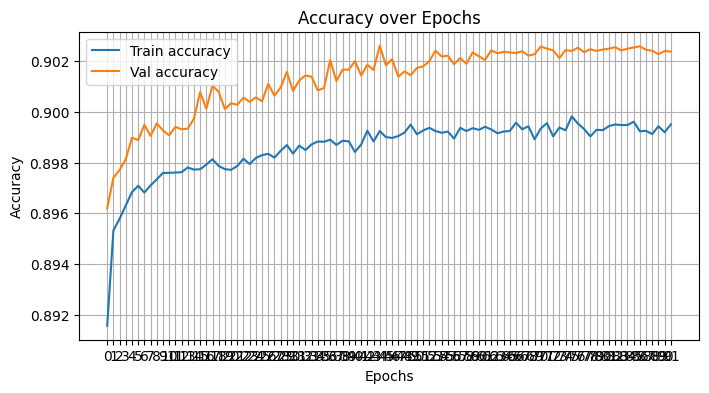

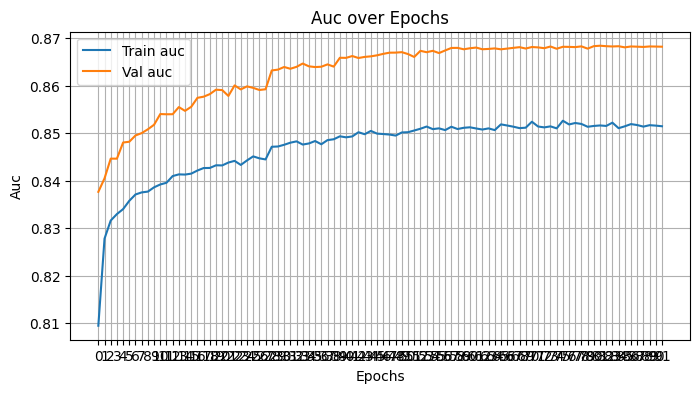

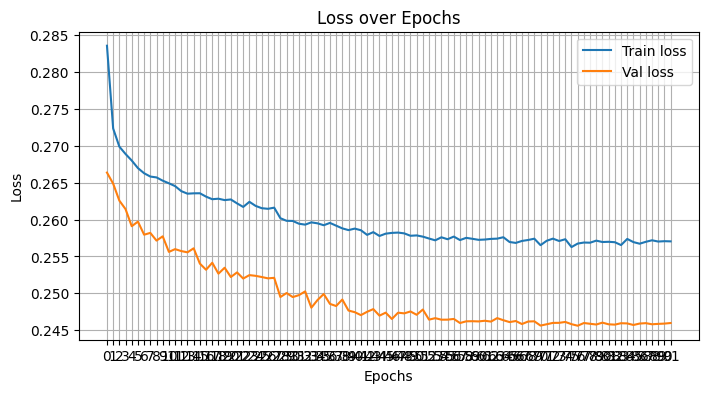

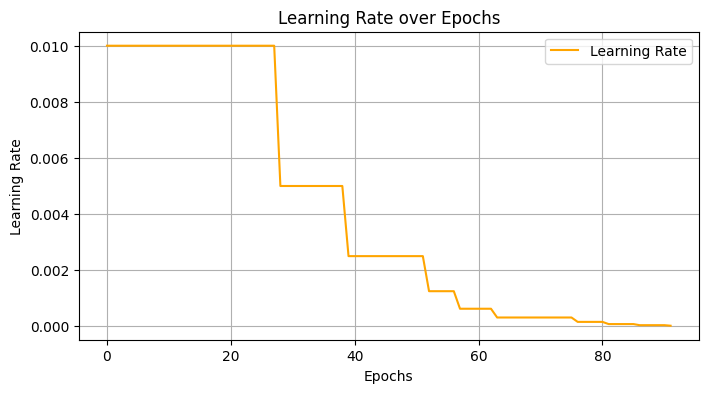

In [43]:
metrics = []
for key in history.history.keys():
    if not key.startswith('val_') and key != 'learning_rate':
        metrics.append(key)

metrics = sorted(metrics)  # optional: sorted for consistent order
print("Selected metrics:", metrics)

def plot_training_history(history):
    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.plot(history.history[metric], label=f'Train {metric}')
        
        val_metric_key = f'val_{metric}'
        if val_metric_key in history.history:
            plt.plot(history.history[val_metric_key], label=f'Val {metric}')
        
        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.xticks(range(len(history.history[metric])))  # optional
        plt.show()

    # Optional: plot learning rate
    if 'learning_rate' in history.history:
        plt.figure(figsize=(8, 4))
        plt.plot(history.history['learning_rate'], label='Learning Rate', color='orange')
        plt.title('Learning Rate over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Learning Rate')
        plt.grid(True)
        plt.legend()
        plt.show()

plot_training_history(history)


### Step 5 : Making the predictions and evaluating the model
### Predicting the result of a single observation

In [ ]:
# keras model template - feel free to use other things

class FlatModel(keras.Model):
    NAME = "flat_model"
    def __init__(self,
                 units: int = 32,
                 name: str = None,
                 **kwargs
                 ):
        name = name or self.NAME
        super().__init__(name = name)

        # define trainable layers

    def get_config(self):
        config = super().get_config()
        return config

    def call(self, inputs: list, training: bool = False) -> tf.Variable:
        """
        if the timeline inputs format is being used.

        gmax_race_length                    # (N, 1)
        surface                             # (N, 1)
        distance_remaining                  # (N, timesteps)
        speed                               # (N, timesteps)
        acceleration                        # (N, timesteps)
        stride_frequency                    # (N, timesteps)
        weighted_average_speed              # (N, timesteps)
        weighted_average_acceleration       # (N, timesteps)
        weighted_average_stride_frequency   # (N, timesteps)
        starting_probability                # (N, 1)
        """
        if isinstance(inputs, dict):
            race_length = inputs["gmax_race_length"]
            surface = inputs["surface"]
            distance_remaining = inputs["distance_remaining"]
            instant_speed = inputs["speed"]
            instant_acceleration = inputs["acceleration"]
            instant_stride_frequency = inputs["stride_frequency"]
            weighted_average_speed = inputs["weighted_average_speed"]
            weighted_average_acceleration = inputs["weighted_average_acceleration"]
            weighted_average_stride_frequency = inputs["weighted_average_stride_frequency"]
            starting_probability = inputs["starting_probabilities"]
        elif isinstance(inputs, list):
            (
            race_length,
            surface,
            distance_remaining,
            instant_speed,
            instant_acceleration,
            instant_stride_frequency,
            weighted_average_speed,
            weighted_average_acceleration,
            weighted_average_stride_frequency,
            starting_probability
            ) = inputs
        
        # complete model call method here

        return starting_probability



In [ ]:
# create model predictions
for (race_id, timestamp), grp in test_df.groupby(["race_id", "timestamp"]):
    pass
    #test_df.loc[grp.index, "prob_model"] = ...

In [44]:
# Function to create ensemble predictions
def create_ensemble_predictions(model_list, X, weights=None):
    """Create ensemble predictions from multiple models"""
    all_preds = []
    
    for model in model_list:
        if isinstance(model, tf.keras.Model):
            preds = model.predict(X).flatten()
        else:
            preds = model.predict_proba(X)[:, 1]
        all_preds.append(preds)
    
    # Default to equal weights if not provided
    if weights is None:
        weights = [1/len(model_list)] * len(model_list)
    
    # Weighted average
    ensemble_preds = np.zeros_like(all_preds[0])
    for i, preds in enumerate(all_preds):
        ensemble_preds += weights[i] * preds
    
    return ensemble_preds

In [45]:
def create_ensemble_predictions_custom_inputs(models, inputs, weights=None):
    """Ensemble predictions for models with different input Xs"""
    assert len(models) == len(inputs), "Each model must have a corresponding input set"
    
    all_preds = []
    for model, X in zip(models, inputs):
        if isinstance(model, tf.keras.Model):
            preds = model.predict(X).flatten()
        else:
            preds = model.predict_proba(X)[:, 1]
        all_preds.append(preds)
    
    if weights is None:
        weights = [1/len(models)] * len(models)
    
    ensemble_preds = np.zeros_like(all_preds[0])
    for i, preds in enumerate(all_preds):
        ensemble_preds += weights[i] * preds
    
    return ensemble_preds


#### Optimize Weights with scipy.optimize Use continuous optimization (faster & more flexible):

In [46]:
from sklearn.metrics import roc_auc_score
from scipy.optimize import minimize


def loss_fn(w, models, inputs, y_true):
    if any(wi < 0 for wi in w) or abs(sum(w) - 1.0) > 1e-6:
        return 1e6
    preds = create_ensemble_predictions_custom_inputs(models, inputs, weights=w)
    score = roc_auc_score(y_true, preds)
    print(f"Weights: {w}, AUC: {score}")
    return -score

res = minimize(
    loss_fn,
    x0 = [0.5, 0.3, 0.2],
    args=(
        [ann, xgb_model_final, rf_final],
        [X_val_ANN, X_val_sel, X_val_sel],
        y_val_sel
    ),
    method='SLSQP',
    bounds=[(0, 1)] * 3,
    constraints={'type': 'eq', 'fun': lambda w: sum(w) - 1},
    options={'disp': True, 'maxiter': 100}
)

print("Success:", res.success)
print("Message:", res.message)
print("Number of iterations:", res.nit)

print("Best weights:", res.x)
print("Best AUC:", -res.fun)


2717/2717 ━━━━━━━━━━━━━━━━━━━━ 3s 939us/step
Weights: [0.5 0.3 0.2], AUC: 0.9099288014670002
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 2s 881us/step
Weights: [0.50000001 0.3        0.2       ], AUC: 0.9099288014670002
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step
Weights: [0.5        0.30000001 0.2       ], AUC: 0.9099288014670002
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 3s 928us/step
Weights: [0.5        0.3        0.20000001], AUC: 0.9099288034649005
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 2s 788us/step
Weights: [0.45530773 0.25530773 0.28938455], AUC: 0.9073972114069739
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 2s 786us/step
Weights: [0.48155103 0.28155103 0.23689793], AUC: 0.9089359942037023
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 3s 980us/step
Weights: [0.4923173 0.2923173 0.2153654], AUC: 0.909524377168506
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 3s 953us/step
Weights: [0.496789   0.296789   0.20642201], AUC: 0.9097611589863221
2717/2717 ━━━━━━━━━━━━━━━━━━━━ 3s 958us/step
Weights: [0.49865614 0.29865614 0.20268771], AUC: 0.9098590527702765

In [48]:
#y_pred_ann = ann.predict(X_test_ANN).flatten()
#y_pred_gb = gb_model.predict_proba(X_test_ANN)[:, 1]
y_pred_xgb = xgb_model_final.predict_proba(X_test)[:, 1]
y_pred_RF = rf_final.predict_proba(X_test)[:, 1]
y_pred_ST = test_df.starting_probability.copy()

# ANN predictions
test_df = test_df.assign(
    prob_model_ann = create_ensemble_predictions_custom_inputs(
        [ann, gb_model], 
        [X_test_ANN,X_test_ANN], 
        weights=[0.6, 0.4]  
    ),
)

y_pred_ann = test_df["prob_model_ann"].values

test_df = test_df.assign(
    prob_model_Ultimate=create_ensemble_predictions_custom_inputs(
        [ann, xgb_model_final, rf_final],
        [X_test_ANN, X_test, X_test],
        weights =  [0.5, 0.3, 0.2]
        #weights = [0.49623648, 0.33709758, 0.16666594]
    )
)

y_pred_ultimate = test_df["prob_model_Ultimate"].values

# XGBoost predictions
test_df = test_df.assign(
     prob_model_xgb = y_pred_xgb,
 )

# Random forest
test_df = test_df.assign(
     prob_model_RF = y_pred_RF,
 )

# For baseline comparison (starting probability)
test_df = test_df.assign(
    prob_starting_probability = y_pred_ST,
)

4305/4305 ━━━━━━━━━━━━━━━━━━━━ 3s 659us/step
4305/4305 ━━━━━━━━━━━━━━━━━━━━ 4s 963us/step


In [49]:
# evaluation functions

def compute_r2(probabilities: np.ndarray,
               result: np.ndarray
               ) -> float:
    """
    r2 score as detailed in the Benter hong kong paper.
    scores close to 1 imply a very good model.
    """
    # dead heats not allowed, maybe adapt later to allow it
    probabilities = probabilities / np.sum(probabilities)
    winner_probability = probabilities[result == 1.][0]
    p_baseline = np.mean(probabilities)
    if p_baseline == 1:
        p_baseline = 0.9999
    r2_score = 1 - ((1 - winner_probability) ** 2) / ((1 - p_baseline) ** 2)
    return r2_score

for name, grp in tqdm(test_df.groupby(["race_id", "timestamp"])):
    result = grp.pa_finish_position.to_numpy().reshape(-1) == 1
    if not np.any(result):
        test_df.loc[grp.index, "r2_score_exchange"] = np.nan
        test_df.loc[grp.index, "r2_score_starting_pro"] = np.nan
        test_df.loc[grp.index, "r2_score_ann"] = np.nan
        test_df.loc[grp.index, "r2_score_xgb"] = np.nan
        test_df.loc[grp.index, "r2_score_RF"] = np.nan
        test_df.loc[grp.index, "r2_score_Ultimate"] = np.nan
        continue
    test_df.loc[grp.index, "r2_score_exchange"] = compute_r2(grp["prob_exchange"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_starting_pro"] = compute_r2(grp["prob_starting_probability"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_ann"] = compute_r2(grp["prob_model_ann"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_xgb"] = compute_r2(grp["prob_model_xgb"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_RF"] = compute_r2(grp["prob_model_RF"].to_numpy().reshape(-1), result)
    test_df.loc[grp.index, "r2_score_Ultimate"] = compute_r2(grp["prob_model_Ultimate"].to_numpy().reshape(-1), result)

100%|██████████| 15821/15821 [00:19<00:00, 795.31it/s]


In [51]:
def plot_r2_scores(df: pd.DataFrame):
    distance_bounds = [
        10000, 1200, 1100, 1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 0
        ]

    model_data = []
    exchange_data = []
    ann_data = []
    xgb_data = []
    RF_data = []
    Ultimate_data = []

    for upper, lower in zip(distance_bounds, distance_bounds[1:]):
        grp = df[df.P.between(lower, upper)]
        # get unique [race_id, timestamp] r2 scores
        Ultimate_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_Ultimate"].mean()
        )
        ann_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_ann"].mean()
        )
        xgb_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_xgb"].mean()
        )
        RF_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_RF"].mean()            
        )
        model_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_starting_pro"].mean()
        )
        exchange_data.append(
            grp.drop_duplicates(subset=["race_id", "timestamp"])["r2_score_exchange"].mean()
        )

    fig = go.Figure()
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = Ultimate_data,
            name = " Ultimate Model",
            marker_color = "darksalmon"
            )
    )
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = ann_data,
            name = " ANN Model",
            marker_color = "blue"
            )
    )
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = xgb_data,
            name = " XGB Model",
            marker_color = "purple"
            )
    )            
    fig.add_trace(
            go.Bar(
                x = distance_bounds[1:],
                y = RF_data,
                name = " RF Model",
                marker_color = "green"
                )            
    )
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = model_data,
            name = " Starting Pro Model",
            marker_color = "red"
            )
    )
    fig.add_trace(
        go.Bar(
            x = distance_bounds[1:],
            y = exchange_data,
            name = "Exchange",
            marker_color = "gold"
            )
    )
    fig.update_layout(
        title = "R2 predictive power scores. Higher is better",
        xaxis_title = "Distance Remaining",
        yaxis_title = "R2 score",
    )
    fig.show()


ALL_COLOURS = {
    "01": "red",
    "02": "blue",
    "03": "silver",
    "04": "forestgreen",
    "05": "black",
    "06": "yellow",
    "07": "magenta",
    "08": "grey",
    "09": "purple",
    "10": "orange",
    "11": "olivedrab",
    "12": "darksalmon",
    "13": "darkred",
    "14": "saddlebrown",
    "15": "navy",
    "16": "chartreuse",
    "1A": "palevioletred",
    "2B": "turquoise"
}

def plot_predictions(df: pd.DataFrame) -> None:
    """
    group by runners and plot each runner prediction timeline
    """
    placers = df[df.pa_finish_position < 4].runner_id.unique().tolist()
    winners = df[df.pa_finish_position == 1].runner_id.unique().tolist()
    if df.empty:
        return
    fig = go.Figure()
    colours = iter(ALL_COLOURS.values())
    for runner_id, runner in df.groupby("runner_id"):
        colour = next(colours)
        fig.add_trace(
            go.Scatter(
                x = runner.timestamp,
                y = runner["prob_model"],
                mode = "lines+markers",
                name = f"{runner_id} - Model Prob",
                marker = {
                    "color": colour,
                    "size": 4
                },
                line = {
                    "color": colour,
                    "width": 3,
                    "dash": "solid"
                },
                opacity = 0.9,
                visible = "legendonly" if runner_id not in placers else None
            )
        )

        fig.add_trace(
            go.Scatter(
                x = runner.timestamp,
                y = 1. / runner["prob_exchange"],
                mode = "lines+markers",
                name = "{0} - {1}".format("Exchange prob", runner_id),
                marker = {
                    "color": colour,
                    "size": 3.5
                },
                line = {
                    "color": colour,
                    "width": 3,
                    "dash": "dot"
                },
                opacity = 0.65,
                visible = "legendonly" if runner_id not in placers else None
            )
        )
    fig.update_layout(
        title = "Timeline of model predictions - {0}, Winner: {2}".format(df.race_id.iloc[0], winners),
        xaxis_title = "Timeline",
        yaxis_title = "Probability",
        showlegend = True
    )
    fig.show()

In [52]:
plot_r2_scores(test_df)

#### Evaluate All Your Models

In [102]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# True labels
y_true = y_test  

# Initialize a dictionary to store metrics
results = {}

def evaluate_model(y_true, y_pred_proba, threshold=0.5):
    y_pred_binary = (y_pred_proba >= threshold).astype(int)  # Convert probabilities to 0/1
    return {
        "ROC-AUC": roc_auc_score(y_true, y_pred_proba),
        "Accuracy": accuracy_score(y_true, y_pred_binary),
        "Precision": precision_score(y_true, y_pred_binary),
        "Recall": recall_score(y_true, y_pred_binary),
        "F1-Score": f1_score(y_true, y_pred_binary)
    }

# Evaluate each model
results['Ultimate'] = evaluate_model(y_true, y_pred_ultimate)
results['ANN'] = evaluate_model(y_true, y_pred_ann)
results['XGBoost'] = evaluate_model(y_true, y_pred_xgb)
results['RandomForest'] = evaluate_model(y_true, y_pred_RF)
results['StartingProbability (baseline)'] = evaluate_model(y_true, y_pred_ST)

results_df = pd.DataFrame(results).T
print(results_df.round(4))


                                ROC-AUC  Accuracy  Precision  Recall  F1-Score
Ultimate                         0.8301    0.8967     0.6648  0.1598    0.2577
ANN                              0.8338    0.8966     0.6526  0.1679    0.2671
XGBoost                          0.8187    0.8947     0.5981  0.1866    0.2845
RandomForest                     0.8310    0.8955     0.7138  0.1143    0.1970
StartingProbability (baseline)   0.7813    0.8878     0.4986  0.0499    0.0907


❗ Recall and F1-Score are very low, meaning models are not catching the positive (win) cases well.

| Metric Name   | Description (Why It’s Likely Useful)                                                                                         |
|---------------|------------------------------------------------------------------------------------------------------------------------------|
| ROC-AUC       | Area Under the Receiver Operating Characteristic Curve. Measures how well the model distinguishes between classes. Especially useful for imbalanced datasets. AUC = 1.0 → Perfect, AUC = 0.5 → Random guess. Higher is better. |
| Accuracy      | Percentage of total predictions that were correct. Useful when classes are balanced, but can be misleading with imbalance.    |
| Precision     | Of all predicted positives, how many were actually positive? High precision = fewer false positives. Important when false positives are costly. |
| Recall        | Of all actual positives, how many did the model catch? High recall = fewer false negatives. Critical in high-sensitivity applications. |
| F1-Score      | Harmonic mean of precision and recall. Balances both when there's class imbalance. Useful when you care about both precision and recall. |
